# Zadanie domowe - EDA Danych dotyczących Irysów

* Twoim zadaniem jest wykonanie analizy danych zawartych w załączonym pliku CSV (`25__iris.csv`).
* Plik znajduje się pod video. Pamiętaj, żeby wrzucić plik do tego samego folderu, w którym znajduje się ten notebook.
* Wykorzystaj nowo nabytą wiedzę z biblioteki `Pandas`
* Jeżeli jest taka konieczność posiłkuj się [code explainerem](https://codeexplainer.imprv.ai/) lub / i [data chatterem](https://datachatter.imprv.ai/) (który również te dane ma dostępne).
* Prześlij na discordzie notebook z rozwiązaniem (`#modul-4-zad1`)
* Pamiętaj:

1. Nie spiesz się
2. Potraktuj zadanie domowe jak prawdziwy projekt
3. Dodawaj opisy, obserwacje, wnioski
4. Dodaj wizualizacje
5. Dodaj konkluzję i wnioski końcowe

Powodzenia!!! I mega zabawy!

## O Danych

Zbiór danych zawiera informacje o trzech gatunkach irysów: Iris setosa, Iris versicolor, i Iris virginica.

Dane obejmują pomiary czterech cech: długość i szerokość działki kielicha oraz długość i szerokość płatka.

Każdy wiersz w zbiorze danych reprezentuje pojedynczy kwiat, a wartości pomiarów są podane w centymetrach.

Zbiór składa się z 150 próbek, po 50 dla każdego gatunku, i jest szeroko stosowany jako podstawowy zbiór danych do
testowania algorytmów klasyfikacji oraz w nauce o danych i uczeniu maszynowym.

Kolumny:
* **długość kielicha (sepal length)** - Długość kielicha w cm
* **szerokość kielicha (sepal width)** - Szerokość kielicha w cm
* **długość płatka (petal length)** - Długość płatka w cm
* **szerokość płatka (petal width)** - Szerokość płatka w cm
* **klasa (class)** - Klasa irysa (setosa, versicolor, virginica)

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('25__iris.csv', sep=",")
df

,długość kielicha (sepal length),szerokość kielicha (sepal width),długość płatka (petal length),szerokość płatka (petal width),klasa (class)
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [7]:
df.columns = ['dl kielicha', 'szer kielicha', 'dl platka', 'szer platka', 'gatunek'] # zmiana niepraktycznie długich nazw kolumn
df

,dl kielicha,szer kielicha,dl platka,szer platka,gatunek
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dl kielicha    150 non-null    float64
 1   szer kielicha  150 non-null    float64
 2   dl platka      150 non-null    float64
 3   szer platka    150 non-null    float64
 4   gatunek        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [12]:
# otrzymane dane informują o 4 kolumnach numerycznych, jednej typu object /string/, w całym df nie występują dane brakujące. 
df.sample(20)

,dl kielicha,szer kielicha,dl platka,szer platka,gatunek
148,6.2,3.4,5.4,2.3,Iris-virginica
49,5.0,3.3,1.4,0.2,Iris-setosa
19,5.1,3.8,1.5,0.3,Iris-setosa
13,4.3,3.0,1.1,0.1,Iris-setosa
50,7.0,3.2,4.7,1.4,Iris-versicolor
101,5.8,2.7,5.1,1.9,Iris-virginica
76,6.8,2.8,4.8,1.4,Iris-versicolor
123,6.3,2.7,4.9,1.8,Iris-virginica
69,5.6,2.5,3.9,1.1,Iris-versicolor
94,5.6,2.7,4.2,1.3,Iris-versicolor


In [13]:
# sprawdzenie hipotezy, że w całym df nie ma wartości brakujących
df.isnull()

,dl kielicha,szer kielicha,dl platka,szer platka,gatunek
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [15]:
# sprawdzenie ile jest danych unikatowych w kolumnie "gatunek"
df['gatunek'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [17]:
#chcę się dowiedzieć ile wierszy jest powiązanych z wartościami unikatowymi
df['gatunek'].describe()

count             150
unique              3
top       Iris-setosa
freq               50
Name: gatunek, dtype: object

### Ogólny przegląd i analiza danych pokazuje, że nie ma brakujących wartości,dane są starannie wprowadzone, konsystentne, nie ma potrzeby uzupełniania ich w procesie transformacji danych

## Kolejny etap analizy poświęcony jest cechom badanych gatunków, czyli rozmiarów ich kielicha i listków

In [66]:
# upewniamy się, jak liczne są zbiory określające każdy gatunek /ile wierszy określa daną grupę/
df.groupby('gatunek', as_index=False)['dl kielicha'].count()

,gatunek,dl kielicha
0,Iris-setosa,50
1,Iris-versicolor,50
2,Iris-virginica,50


In [67]:
# Kazdy z badanych gatunków reprezentowany jest przez równą ilość danych, w 50 wierszach dla każdego gatunku. Poniżej analiza wszystkich danych liczbowych /wielkości max, min,średnia, mediana i odchylenie st.
df.groupby('gatunek', as_index=False).agg({
    'dl kielicha': ['min', 'max', 'mean', 'median', 'std'],
    'szer kielicha': ['min', 'max', 'mean', 'median', 'std'],
    'dl platka': ['min', 'max', 'mean', 'median', 'std'],
    'szer platka':['min', 'max', 'mean', 'median', 'std'],
})

gatunek dl kielicha                              szer kielicha  \
                           min  max   mean median       std           min   
0      Iris-setosa         4.3  5.8  5.006    5.0  0.352490           2.3   
1  Iris-versicolor         4.9  7.0  5.936    5.9  0.516171           2.0   
2   Iris-virginica         4.9  7.9  6.588    6.5  0.635880           2.2   

                      ... dl platka                              szer platka  \
   max   mean median  ...       min  max   mean median       std         min   
0  4.4  3.418    3.4  ...       1.0  1.9  1.464   1.50  0.173511         0.1   
1  3.4  2.770    2.8  ...       3.0  5.1  4.260   4.35  0.469911         1.0   
2  3.8  2.974    3.0  ...       4.5  6.9  5.552   5.55  0.551895         1.4   

                                
   max   mean median       std  
0  0.6  0.244    0.2  0.107210  
1  1.8  1.326    1.3  0.197753  
2  2.5  2.026    2.0  0.274650  

[3 rows x 21 columns]

## Graficzna prezentacja średnich danych liczbowych dla trzech badanych gatunków kwiata Irys: bar plot i scatter plot

<Axes: title={'center': 'Średnie wartości dł. i szer. kielicha oraz płatków kwiatu badanych gatunków'}, xlabel='gatunek'>

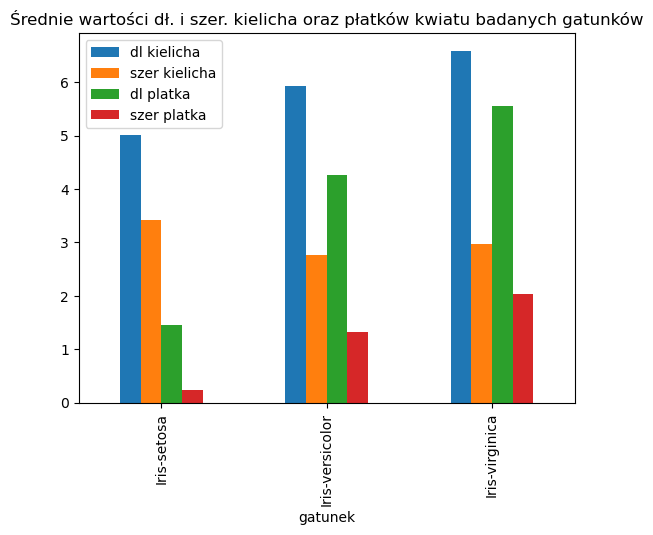

In [85]:
df.groupby('gatunek').mean().plot(kind='bar',title='Średnie wartości dł. i szer. kielicha oraz płatków kwiatu badanych gatunków')

### Bar plot wskazał, że gatunki Irysa różnią się między sobą długością i szerokością zarówno kielicha jak i płatków. Powszechnie sądzi się, że wielkość kielicha kwiatu oraz płatków świadczą o atrakcyjności kwiatu. Z tego punktu widzenia namniej atrakcyjny jest Iris-setoza, najbardziej Iris-virginica. Zauważalna jest niezgodna ze standardowym myśleniem szerokość kielicha, w gatunku ocenianym za najmniej okazały, do szerokości płatków.  

### Pomiary otrzymane z obserwacji gatunków irisa pokazują, że gatunek Iris-setoza wyłąmuje się ze standardu obserwacji

### Silna, widoczna na scatter plot poniżej, zależność między długością płatków i długością kielicha kwiatu jest mniej oczywista, przy porównywaniu poddana jest szerokości kielicha i szerokości płatka. Niestandardowe wyniki pomiarów szerokości kielicha wprowadzają niepokój poznawczy przy analizie scatter plot nr 2.

<Axes: xlabel='dl kielicha', ylabel='dl platka'>

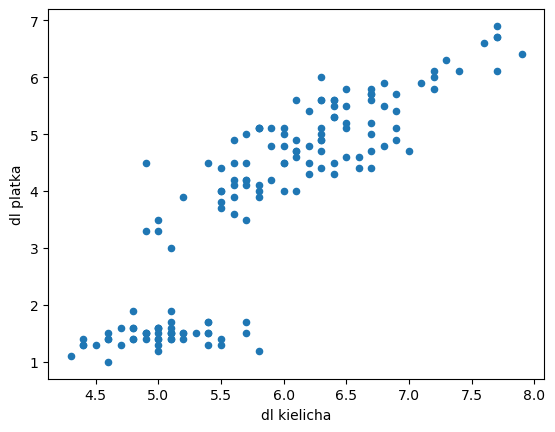

In [90]:

df.plot(kind='scatter', x='dl kielicha', y='dl platka')

<Axes: xlabel='szer kielicha', ylabel='szer platka'>

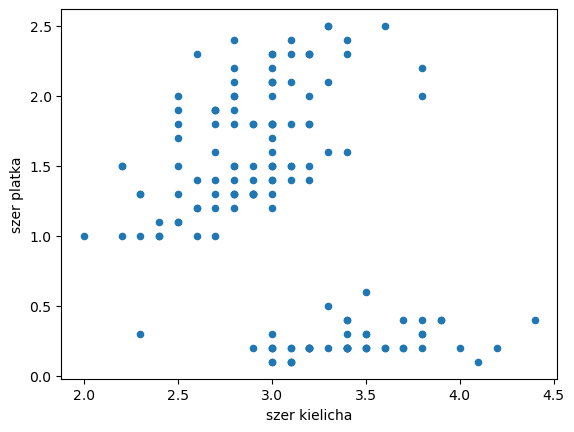

In [91]:
df.plot(kind='scatter', x='szer kielicha', y='szer platka')

## Zwartość danych w tym odchylenia standardowe prezentują poświęcone wszystkim gatunkom box ploty i histogramy.

In [111]:
setoza_df=df.iloc[1:50].copy()
setoza_df

,dl kielicha,szer kielicha,dl platka,szer platka,gatunek
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa
10,5.4,3.7,1.5,0.2,Iris-setosa


<Axes: >

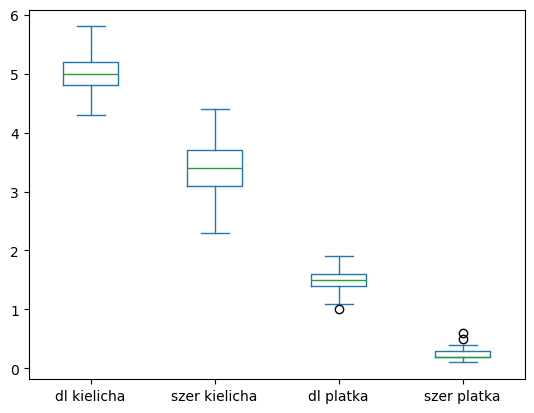

In [114]:
setoza_df.plot(kind='box')

In [108]:
versicolor_df=df.iloc[51:100].copy()
versicolor_df

,dl kielicha,szer kielicha,dl platka,szer platka,gatunek
51,6.4,3.2,4.5,1.5,Iris-versicolor
52,6.9,3.1,4.9,1.5,Iris-versicolor
53,5.5,2.3,4.0,1.3,Iris-versicolor
54,6.5,2.8,4.6,1.5,Iris-versicolor
55,5.7,2.8,4.5,1.3,Iris-versicolor
56,6.3,3.3,4.7,1.6,Iris-versicolor
57,4.9,2.4,3.3,1.0,Iris-versicolor
58,6.6,2.9,4.6,1.3,Iris-versicolor
59,5.2,2.7,3.9,1.4,Iris-versicolor
60,5.0,2.0,3.5,1.0,Iris-versicolor


<Axes: >

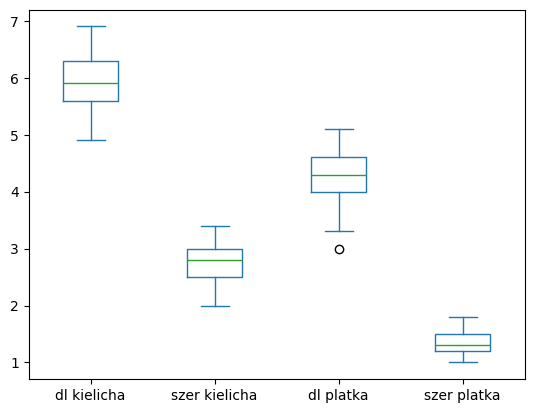

In [112]:
versicolor_df.plot(kind='box')

<Axes: >

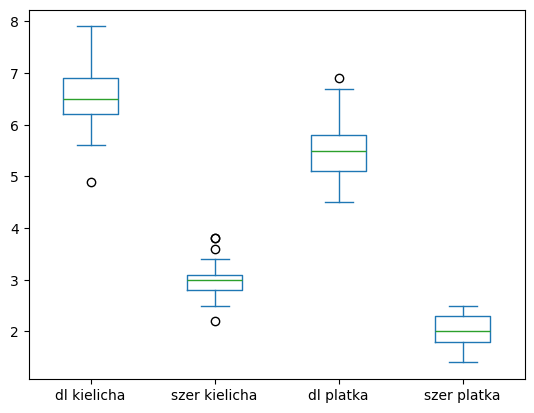

In [76]:
virginica_df=df.iloc[101:150].copy()
virginica_df.plot(kind='box')

array([[<Axes: title={'center': 'dl kielicha'}>,
        <Axes: title={'center': 'szer kielicha'}>],
       [<Axes: title={'center': 'dl platka'}>,
        <Axes: title={'center': 'szer platka'}>]], dtype=object)

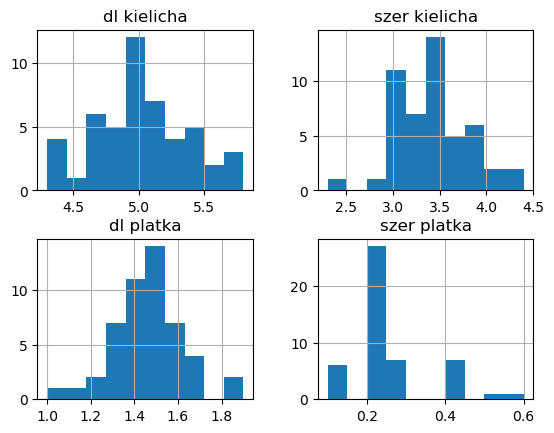

In [49]:
setoza_df.hist() # Poniżej histogramy charakteryzujące regularność budowy płątków i kielichów kwiatów poszczególnych gatunków

array([[<Axes: title={'center': 'dl kielicha'}>,
        <Axes: title={'center': 'szer kielicha'}>],
       [<Axes: title={'center': 'dl platka'}>,
        <Axes: title={'center': 'szer platka'}>]], dtype=object)

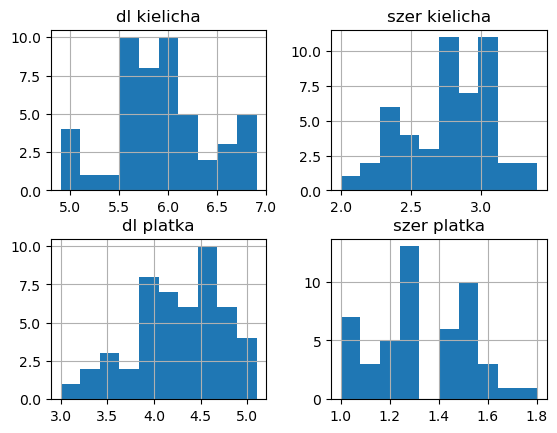

In [50]:
versicolor_df.hist()

array([[<Axes: title={'center': 'dl kielicha'}>,
        <Axes: title={'center': 'szer kielicha'}>],
       [<Axes: title={'center': 'dl platka'}>,
        <Axes: title={'center': 'szer platka'}>]], dtype=object)

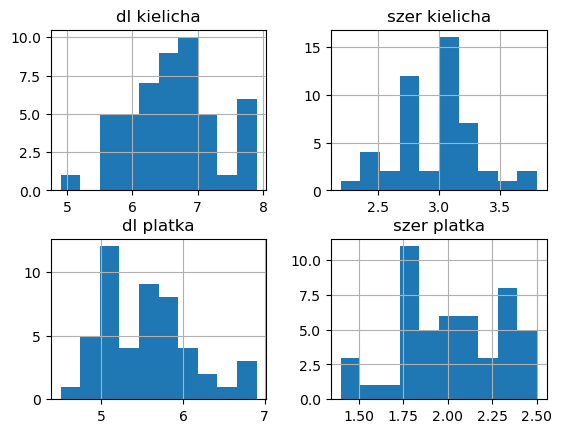

In [51]:
virginica_df.hist()

### Zbadanie corelacji między badanymi wartościami 

In [107]:
df[['dl kielicha', 'szer kielicha', 'dl platka', 'szer platka']].corr()

,dl kielicha,szer kielicha,dl platka,szer platka
dl kielicha,1.000000,-0.109369,0.871754,0.817954
szer kielicha,-0.109369,1.000000,-0.420516,-0.356544
dl platka,0.871754,-0.420516,1.000000,0.962757
szer platka,0.817954,-0.356544,0.962757,1.000000


### Ostatnie zadanie - zbadanie corelacji między długością i szerokością kielichów kwiatów jak i dł i szer płatków kwiatów w całym df badanego zbioru. Widzimy małą ujemną corelacjęz między szerokością kielicha kwiatu z jego długością oraz wyraźną ujemną korelację z długością i grubością kwiatowych płatków oraz bardzo wyraźną dodatnią corelację między długością kielicha a długością i szerokością płatków kwiatów.

# WNIOSKI

* Przegląd i analiza danych pokazuje, że dane zostały starannie zebrane i skrupulatnie /z zastrzeżeniem uwagi umieszczonej w ostatnim punkcie części wnioskowej/ wpisane do zestawienia. Badanie brakujących danych pokazuje że zbiór danych nie zawiera pomyłek, nie ma brakujących wartości, dane są konsystentne i nie wymagają uzupełniania ich w procesie traansformacji danych
* Analizowane dane konsekwentnie pokazują, że najmniej atrakcyjnym, z punktu widzenia wielkości kielicha jak i rozmiaru płatków, gatunkiem isisa jest gatunek Iris-setoza.
* Dwa kolejne gatunki: Iris-versicolor oraz Iris-virginica są znacząco bardziej efektowne, co znajduje wyraz w kształcie płatków - są kilkukrotnie dłuższe i szersze. Średnia długość płątka Iris-virginica jest 3,79 raza większa, szerokość zaś szerokość spektakularne 8,3 raza.
* * Analiza box plotów wskazuje, że dane są zwarte, nie ma wiele miejsca na wartości odstające
* Powyższe obserwacje wyraźnie potwierdza badanie corelacji. Widzimy małą ujemną corelacjęz między szerokością kielicha kwiatu z jego długością oraz wyraźną ujemną korelację z długością i grubością kwiatowych płatków oraz bardzo wyraźną dodatnią corelację między długością kielicha a długością i szerokością płatków kwiatów.
* Uwaga. Badanie korelacji, obserwacje danych liczbowych oraaz scatter plot i barplot'ów, wskazują na jedną, nie pasującą do całości wielkość- średnia szerokość kielicha najmniej atrakcyjnego gatunku: Iris-setoza. Wartość ta jest odwrotnie, niż można byłoby się spodziewać, skorelowana z pozostałymi wskazaniami, jest większa niż jej odpowiedniki w Versicolor czy Virginica. Jest to nieoczekiwana obserwacja badania. Może ona świadczyć albo o genetycznej formie dostosowania się gatunku Iris-setosa do specyficznych, mało znanych nauce cech warunków naturalnych w których występuje w przyrodzie /np. Iris-setosa ma taką strategię reprodukcyjną, która wpływa na rozwój i morfologię kielicha/ albo o pomyłce dotyczącej danych kolumny "sepal width'. Wiadomo, że Iris-setosa, jest rośliną pochodzącą z północnych regionów Ameryki, o surowych warunkach naturalnych /słabsza jakość gleb, niskie temperatury, niedobory wilgotności/ a więc bardziej wymagających, niż w przypadku kolejnych dwóch gatunków. To z kolei mogłoby sugerować, że szerokość kielicha, tak jak ma to miejsce w przypadku pozostałych parametrów, powinna być mniejsza. Powyższe sugeruje więc albo dostrzeżenie oryginalnego zachowania się gatunku Iris-setoza albo sprawdzenie poprawności przesłąnych do analizy danych. Gdyby żadna z hipotez nie była prawdziwa być może zasadna byłaby dodatkowa obserwacja gatunku. 
  